In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
from mlxtend.plotting import plot_decision_regions 

In [3]:
df = pd.DataFrame()

In [5]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [7]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

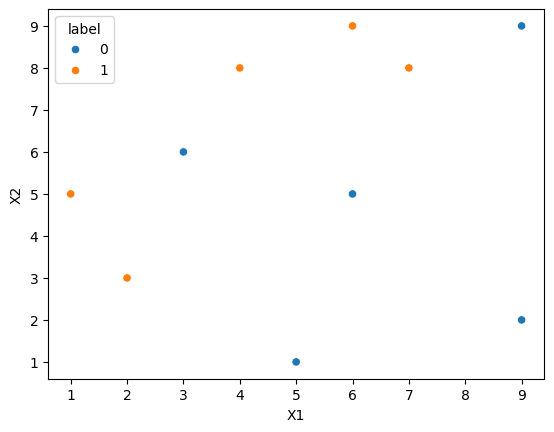

In [11]:
# plot the data
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [13]:
# shape of df
df.shape

(10, 3)

In [15]:
# assign initial weight
df['weights'] = 1/df.shape[0]

In [17]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [19]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [23]:
X = df.iloc[:, 0:2].values
y = df.iloc[:,2].values

In [25]:
# step2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]')]

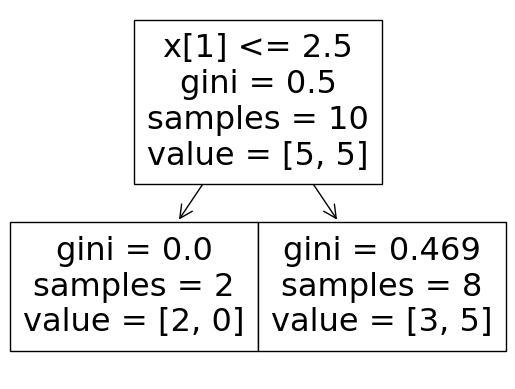

In [27]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

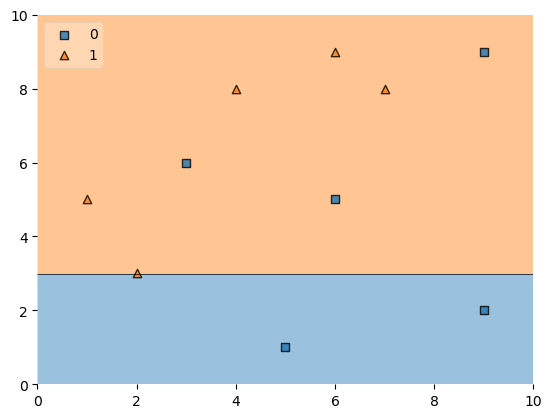

In [29]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [31]:
df['pred'] = dt1.predict(X)

In [33]:
df

,X1,X2,label,weights,pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [137]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error+0.000001))

In [37]:
# step-3 - calculate model weight
alpha = calculate_model_weight(0.3)
alpha

0.42364893019360184

In [39]:
# Step4 - update weights of each row
def update_row_weights(row, alpha = 0.423):
    if row['label'] == row['pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [41]:
df['updated_weights'] = df.apply(update_row_weights, axis=1)

In [43]:
df

,X1,X2,label,weights,pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [45]:
df['updated_weights'].sum()

0.9165153319682015

In [47]:
# normalize weights
df['updated_weights_normalized'] = df['updated_weights']/df['updated_weights'].sum()
df

,X1,X2,label,weights,pred,updated_weights,updated_weights_normalized
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [49]:
df['updated_weights_normalized'].sum()

1.0

In [51]:
df['cumsum_upper'] = np.cumsum(df['updated_weights_normalized'])

In [53]:
df['cumsum_lower'] = df['cumsum_upper'] - df['updated_weights_normalized']

In [55]:
df

,X1,X2,label,weights,pred,updated_weights,updated_weights_normalized,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [59]:
print([i for i in df.iterrows()])

[(0, X1                            1.000000
X2                            5.000000
label                         1.000000
weights                       0.100000
pred                          1.000000
updated_weights               0.065508
updated_weights_normalized    0.071475
cumsum_upper                  0.071475
cumsum_lower                  0.000000
Name: 0, dtype: float64), (1, X1                            2.000000
X2                            3.000000
label                         1.000000
weights                       0.100000
pred                          1.000000
updated_weights               0.065508
updated_weights_normalized    0.071475
cumsum_upper                  0.142950
cumsum_lower                  0.071475
Name: 1, dtype: float64), (2, X1                            3.000000
X2                            6.000000
label                         0.000000
weights                       0.100000
pred                          1.000000
updated_weights               0.152653

In [65]:
print([type(i) for i in df.iterrows()])

[<class 'tuple'>, <class 'tuple'>, <class 'tuple'>, <class 'tuple'>, <class 'tuple'>, <class 'tuple'>, <class 'tuple'>, <class 'tuple'>, <class 'tuple'>, <class 'tuple'>]


In [67]:
print([type(i) for i in df.iterrows()[0]])

TypeError: 'generator' object is not subscriptable

In [73]:
def create_new_dataset(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices

In [75]:
index_values = create_new_dataset(df)
index_values

[5, 6, 5, 6, 8, 4, 5, 6, 7, 2]

In [77]:
second_df = df.iloc[index_values, [0,1,2,3]]
second_df

,X1,X2,label,weights
5,6,9,1,0.1
6,6,5,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
8,9,9,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
2,3,6,0,0.1


In [79]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [83]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [85]:
dt2.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]')]

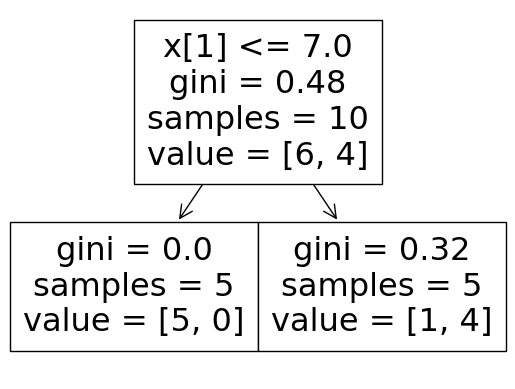

In [87]:
plot_tree(dt2)

<Axes: >

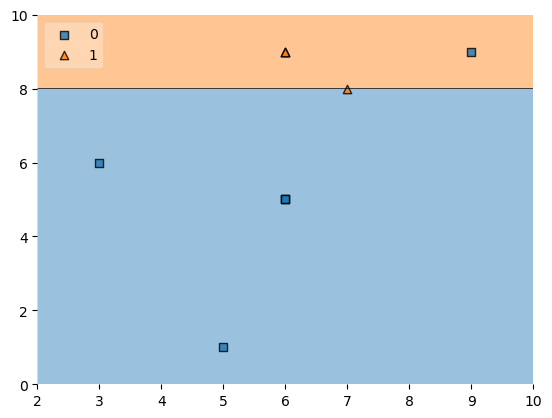

In [89]:
plot_decision_regions(X,y, clf=dt2, legend=2)

In [95]:
second_df['pred'] = dt2.predict(X)

In [97]:
second_df

,X1,X2,label,weights,pred
5,6,9,1,0.1,1
6,6,5,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,0
8,9,9,0,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,0
7,7,8,1,0.1,1
2,3,6,0,0.1,0


In [99]:
alpha2 = calculate_model_weight(0.1)
alpha2

1.0986122886681098

In [103]:
second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1, alpha=1.09)
second_df

,X1,X2,label,weights,pred,updated_weights
5,6,9,1,0.1,1,0.033622
6,6,5,0,0.1,0,0.033622
5,6,9,1,0.1,1,0.033622
6,6,5,0,0.1,0,0.033622
8,9,9,0,0.1,1,0.297427
4,5,1,0,0.1,0,0.033622
5,6,9,1,0.1,1,0.033622
6,6,5,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622


In [105]:
second_df['updated_weights'].sum()

0.6000222515923667

In [107]:
second_df['updated_weights_normalized'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [109]:
second_df['updated_weights_normalized'].sum()

0.9999999999999999

In [111]:
second_df['cumsum_upper'] = np.cumsum(second_df['updated_weights_normalized'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['updated_weights_normalized']

In [113]:
second_df

,X1,X2,label,weights,pred,updated_weights,updated_weights_normalized,cumsum_upper,cumsum_lower
5,6,9,1,0.1,1,0.033622,0.056034,0.056034,0.000000
6,6,5,0,0.1,0,0.033622,0.056034,0.112068,0.056034
5,6,9,1,0.1,1,0.033622,0.056034,0.168102,0.112068
6,6,5,0,0.1,0,0.033622,0.056034,0.224136,0.168102
8,9,9,0,0.1,1,0.297427,0.495694,0.719830,0.224136
4,5,1,0,0.1,0,0.033622,0.056034,0.775864,0.719830
5,6,9,1,0.1,1,0.033622,0.056034,0.831898,0.775864
6,6,5,0,0.1,0,0.033622,0.056034,0.887932,0.831898
7,7,8,1,0.1,1,0.033622,0.056034,0.943966,0.887932
2,3,6,0,0.1,0,0.033622,0.056034,1.000000,0.943966


In [115]:
index_values = create_new_dataset(second_df)

In [117]:
index_values

[8, 2, 8, 6, 8, 8, 8, 8, 2, 5]

In [119]:
third_df = second_df.iloc[index_values, [0,1,2,3]]
third_df

,X1,X2,label,weights
7,7,8,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
4,5,1,0,0.1


In [121]:
dt3 = DecisionTreeClassifier(max_depth=1)

In [123]:
X = third_df.iloc[:,0:2].values
y = third_df.iloc[:,2].values

In [125]:
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [127]:
third_df['pred'] = dt3.predict(X)
third_df

,X1,X2,label,weights,pred
7,7,8,1,0.1,1
5,6,9,1,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,1
4,5,1,0,0.1,0


[Text(0.5, 0.75, 'x[0] <= 5.5\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]')]

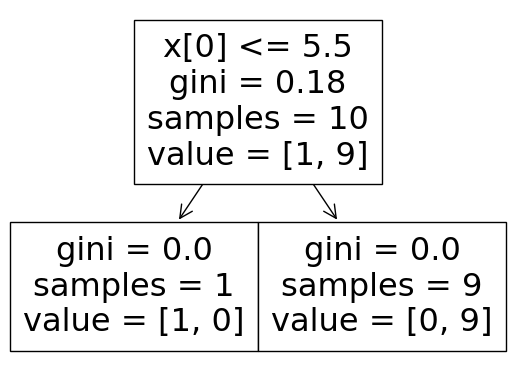

In [129]:
plot_tree(dt3)

<Axes: >

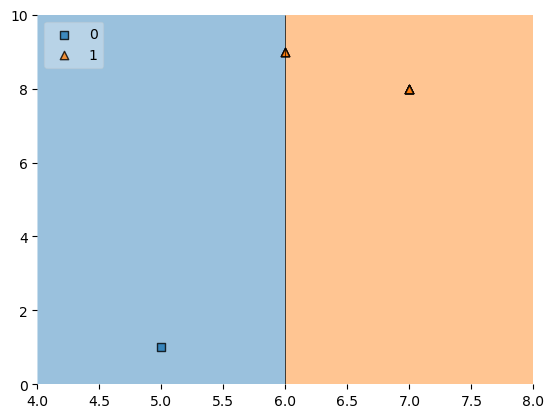

In [131]:
plot_decision_regions(X,y,clf=dt3, legend=2)

In [139]:
alpha3 = calculate_model_weight(error=0)

In [141]:
alpha3

6.907755278982137

In [145]:
print(alpha, alpha2, alpha3)

0.42364893019360184 1.0986122886681098 6.907755278982137


In [149]:
# prediction
query = np.array([1,5]).reshape(1,2)
query

array([[1, 5]])

In [151]:
dt1.predict(query)

array([1], dtype=int64)

In [153]:
dt2.predict(query)

array([0], dtype=int64)

In [155]:
dt3.predict(query)

array([0], dtype=int64)

In [157]:
alpha*(1) + alpha2*(-1) + alpha3*(-1)

-7.582718637456645

In [161]:
np.sign(-7.58)

-1.0

In [163]:
query2 = np.array([9,9]).reshape(1,2)
print(dt1.predict(query2), dt2.predict(query2), dt3.predict(query2))

[1] [1] [1]


In [165]:
alpha*(1) + alpha2*(1) + alpha3*(1)

8.430016497843848

In [169]:
np.sign(8.43)

1.0

In [177]:
# Hyperparameter tuning (Using adaboost class from SKlearn)
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [173]:
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

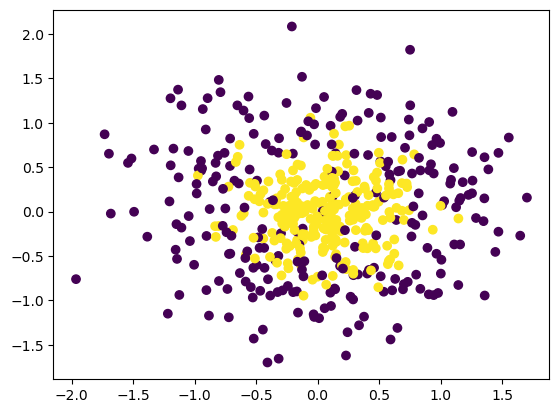

In [179]:
plt.scatter(X[:,0], X[:,1],c=y)

<Axes: >

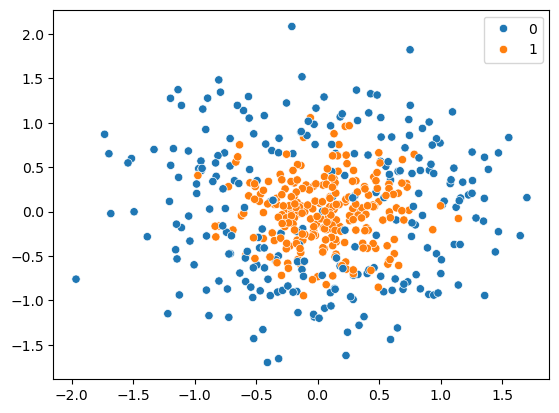

In [181]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [185]:
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.model_selection import cross_val_score

abc = AdaBoostClassifier()
np.mean(cross_val_score(abc,X,y,scoring='accuracy', cv=10))

C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\koy

0.786

In [187]:
abc.fit(X,y)

C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier()

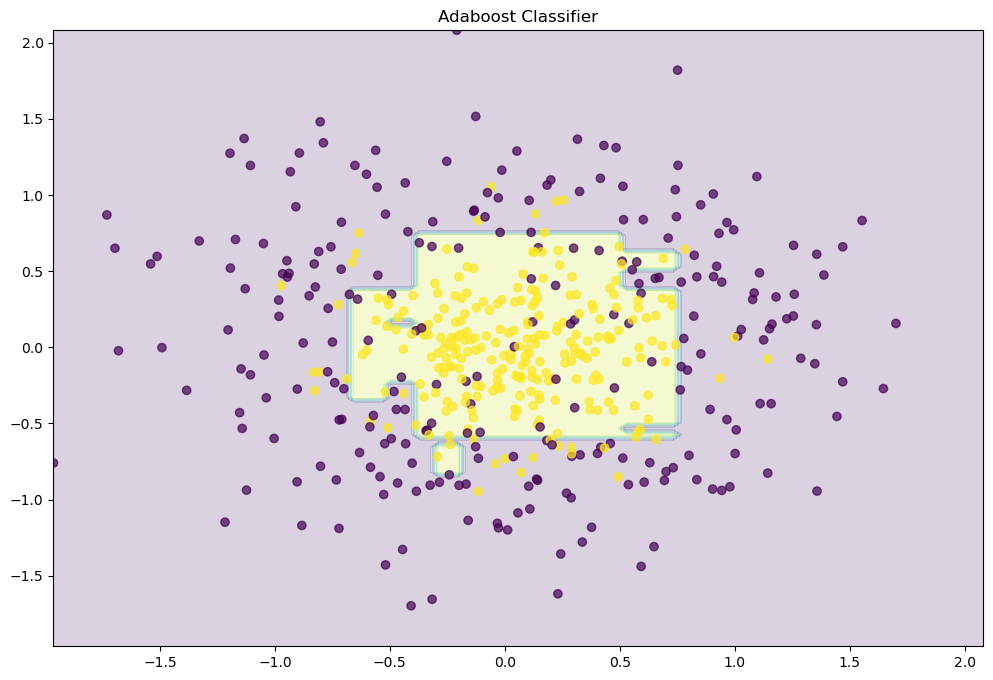

In [193]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12,8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
    plt.title('Adaboost Classifier')
    plt.show()

plot_decision_boundary(clf=abc)

C:\Users\koyel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


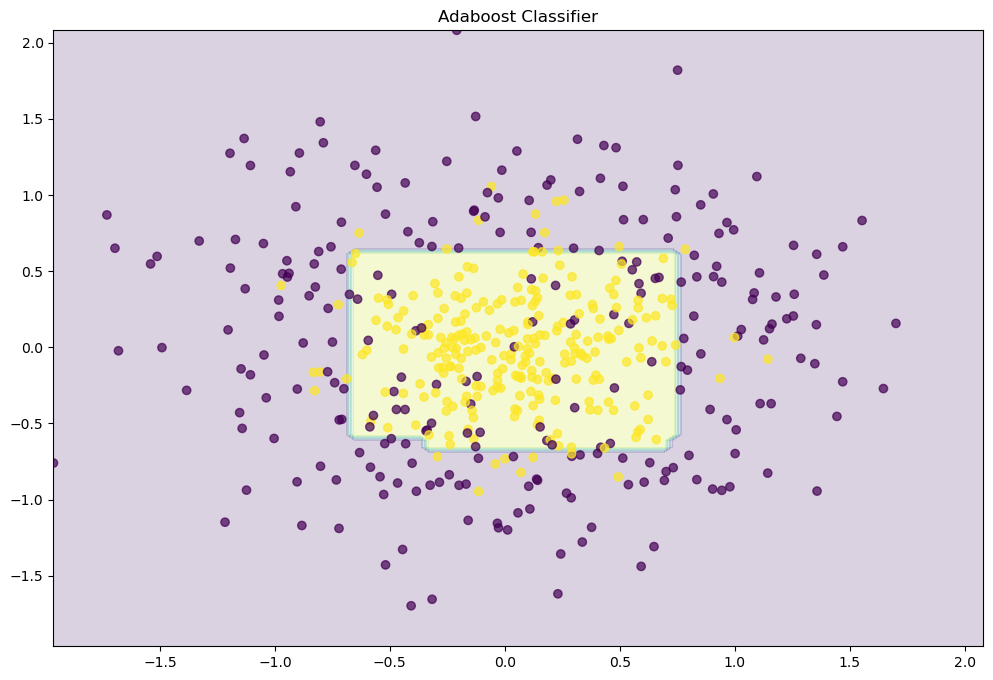

In [197]:
abc = AdaBoostClassifier(n_estimators=1500, learning_rate=0.001)
abc.fit(X,y)
plot_decision_boundary(clf=abc)

In [199]:
from sklearn.model_selection import GridSearchCV

grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
grid['algorithm'] = ['SAMME', 'SAMME.R']

In [201]:
grid_search = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')

# execute the grid search
grid_result = grid_search.fit(X,y)

# summarize the best score and configuration
print("Best: %f using %s", grid_result.best_score_, grid_result.best_params_)

Best: %f using %s 0.8320000000000001 {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 500}
